# Multilayer Perceptron

Dataset: Environment_Temperature_change_E_All_Data_NOFLAG.csv

The dataset explores the mean surface temperature change by country, with annual updates.

The Multilayer Perceptron (MLP) is a fundamental deep learning architecture composed of an input layer, one or more hidden layers, and an output layer. It functions as a non-linear classifier by passing data through weighted connections and activation functions to identify complex relationships within the features. For this climate dataset, the MLP synthesizes 4,811 regional anomalies simultaneously to recognize the high-dimensional "mathematical signature" that defines global warming years.

In [1]:
# import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score

In [3]:
# data loading
# Load dataset
df = pd.read_csv("../data/Environment_Temperature_change_E_All_Data_NOFLAG.csv", encoding='latin1')
# Filter for Temperature change
df = df[df['Element'] == 'Temperature change']

# prepare time-series data
year_cols = [col for col in df.columns if col.startswith('Y')]
data = df[year_cols].transpose()
data.columns = df['Area']
data = data.fillna(data.mean())

# define target
target_country = 'World'
# handle potential MultiIndex/Duplicate column names for target
if isinstance(data[target_country], pd.DataFrame):
    world_series = data[target_country].iloc[:, 0]
else:
    world_series = data[target_country]

# bpinary labels: 1 if change is above median, 0 otherwise
y = (world_series > world_series.median()).astype(int).to_numpy()

# Drop ALL 'World' columns from features X to prevent data leakage
X = data.drop(columns=[col for col in data.columns if target_country in str(col)])

In [4]:
# pre-processing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# standardize data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
##
def relu(Z):
    return np.maximum(0, Z)

def relu_derivative(A):
    return (A > 0).astype(float)

def sigmoid(Z):
    # Stabilized sigmoid to prevent overflow
    return 1 / (1 + np.exp(-np.clip(Z, -20, 20)))

class MultilayerPerceptron:
    def __init__(self, hidden_layers, learning_rate=0.001, max_iter=2000, random_state=42):
        self.hidden_layers = list(hidden_layers)
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.random_state = random_state
        self.loss_history_ = []
        self._rng = np.random.default_rng(random_state)

    def _initialize_parameters(self, n_features):
        layer_sizes = [n_features] + self.hidden_layers + [1]
        self.weights_ = []
        self.biases_ = []
        for i in range(len(layer_sizes) - 1):
            # Xavier/Glorot Initialization for stability
            limit = np.sqrt(6 / (layer_sizes[i] + layer_sizes[i+1]))
            W = self._rng.uniform(-limit, limit, (layer_sizes[i], layer_sizes[i+1]))
            b = np.zeros((1, layer_sizes[i+1]))
            self.weights_.append(W)
            self.biases_.append(b)

    def _forward(self, X):
        activations = [X]
        for i in range(len(self.weights_)):
            Z = activations[-1] @ self.weights_[i] + self.biases_[i]
            A = sigmoid(Z) if i == len(self.weights_) - 1 else relu(Z)
            activations.append(A)
        return activations

    def _backward(self, activations, y):
        y = y.reshape(-1, 1)
        m = y.shape[0]

        # ERROR DIRECTION: (Predictions - Actual)
        delta = activations[-1] - y

        grads_W = []
        grads_b = []

        for i in reversed(range(len(self.weights_))):
            dW = (activations[i].T @ delta) / m
            db = np.sum(delta, axis=0, keepdims=True) / m

            grads_W.insert(0, dW)
            grads_b.insert(0, db)

            if i > 0:
                delta = (delta @ self.weights_[i].T) * relu_derivative(activations[i])

        return grads_W, grads_b

    def fit(self, X, y):
        self._initialize_parameters(X.shape[1])

        for epoch in range(self.max_iter):
            activations = self._forward(X)
            y_pred = activations[-1]

            # Binary Cross Entropy Loss
            epsilon = 1e-15 # prevent log(0)
            loss = -np.mean(y.reshape(-1,1) * np.log(y_pred + epsilon) + (1 - y.reshape(-1,1)) * np.log(1 - y_pred + epsilon))
            self.loss_history_.append(loss)

            grads_W, grads_b = self._backward(activations, y)

            # UPDATE WEIGHTS: Always SUBTRACT the gradient
            for i in range(len(self.weights_)):
                self.weights_[i] -= self.learning_rate * grads_W[i]
                self.biases_[i] -= self.learning_rate * grads_b[i]

        return self

    def predict_proba(self, X):
        return self._forward(X)[-1].ravel()

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

    def score(self, X, y):
        return np.mean(self.predict(X) == y)

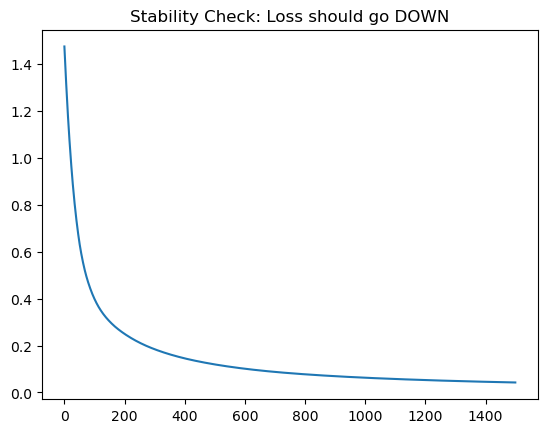

In [6]:
# execution & visualization
# initialize with two hidden layers
mlp = MultilayerPerceptron(hidden_layers=[64], learning_rate=0.0001, max_iter=1500)
mlp.fit(X_train_scaled, y_train)

# Plot
plt.plot(mlp.loss_history_)
plt.title("Stability Check: Loss should go DOWN")
plt.show()

In [7]:
from sklearn.metrics import accuracy_score, classification_report

# prediction from trained MLP
y_pred = mlp.predict(X_test_scaled)

# 2. Calculate and print the overall accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Final Test Accuracy: {accuracy:.4f}")
print("-" * 30)

# 3. Print the detailed Classification Report
# This breaks down performance for 'Low Warming' (0) and 'High Warming' (1)
print("Classification Report:")
print(classification_report(y_test, y_pred))

Final Test Accuracy: 0.7500
------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.67      0.73         6
           1       0.71      0.83      0.77         6

    accuracy                           0.75        12
   macro avg       0.76      0.75      0.75        12
weighted avg       0.76      0.75      0.75        12



MLP was looking at thousands of tiny regional temperature changes simultaneously, finding the mathematical "signature" that defines a global warming year, and refining its internal weights until it could recognize that signature with 75% accuracy.